# Predicción del éxito de atracciones turísticas mediante Deep Learning

## 1. Configuración inicial

### Descripción

En esta sección se prepara el entorno de trabajo del notebook. Se importan las librerías necesarias para manipulación de datos, visualización, procesamiento de imágenes y entrenamiento de modelos en PyTorch.

### Punto clave

Se fijan semillas aleatorias para mejorar la reproducibilidad y se define si el entrenamiento se realizará en CPU o GPU.

In [1]:
# ============================================================
# 1. Configuración inicial
# ============================================================

from pathlib import Path
import random
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch

# ============================================================
# Reproducibilidad
# ============================================================

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# Dispositivo de cómputo
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Device usado:", device)

# ============================================================
# Rutas del proyecto
# ============================================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

CSV_PATH = PROJECT_ROOT / "poi_dataset.csv"
IMAGE_ROOT = PROJECT_ROOT / "data_main"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"

OUTPUTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("\nNOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("CSV_PATH existe:", CSV_PATH.exists())
print("IMAGE_ROOT existe:", IMAGE_ROOT.exists())

Torch: 2.12.1+cu126
CUDA disponible: True
GPU: NVIDIA GeForce RTX 4080 SUPER
Device usado: cuda

NOTEBOOK_DIR: E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final\notebooks
PROJECT_ROOT: E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final
CSV_PATH existe: True
IMAGE_ROOT existe: True


## 2. Carga del dataset

### Descripción

En esta sección se carga el archivo `poi_dataset.csv`, que contiene la información tabular de los puntos de interés turísticos.

### Análisis inicial

Se revisan las dimensiones del dataset, los nombres de las columnas, los tipos de datos, los valores faltantes y las métricas originales de interacción:

- `Visits`
- `Likes`
- `Dislikes`
- `Bookmarks`

Esta inspección permite detectar problemas iniciales antes de preparar los datos para el modelo.

In [2]:
# ============================================================
# 2. Carga del dataset
# ============================================================

df = pd.read_csv(CSV_PATH)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

print("\nColumnas del dataset:")
print(df.columns.tolist())

display(df.head())

Filas: 1569
Columnas: 14

Columnas del dataset:
['id', 'name', 'shortDescription', 'categories', 'tier', 'locationLon', 'locationLat', 'tags', 'xps', 'Visits', 'Likes', 'Dislikes', 'Bookmarks', 'main_image_path']


,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,Galería Fran Reus,La Galería Fran Reus es un espacio dedicado a ...,"['Escultura', 'Pintura']",1,2.642262,39.572694,[],500,10009,422,3582,78,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...
1,e32b3603-a94f-49df-8b31-92445a86377c,Convento de San Plácido,"El Convento de San Plácido en Madrid, fundado ...","['Patrimonio', 'Historia']",1,-3.704467,40.423037,[],500,10010,7743,96,2786,data_main/e32b3603-a94f-49df-8b31-92445a86377c...
2,0123a69b-13ac-4b65-a5d5-71a95560cff5,Instituto Geológico y Minero de España,"El Instituto Geológico y Minero de España, sit...","['Ciencia', 'Patrimonio']",2,-3.699694,40.442045,[],250,10015,3154,874,595,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...
3,390d7d9e-e972-451c-b5e4-f494af15e788,Margarita Gil Roësset,"Margarita Gil Roësset, escultora y poetisa esp...",['Cultura'],1,-3.691228,40.427256,[],500,10011,8559,79,2358,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...
4,023fc1bf-a1cd-4b9f-af78-48792ab1a294,Museo del Traje. Centro de Investigación del P...,"El Museo del Traje de Madrid, fundado en 2004,...","['Patrimonio', 'Cultura']",1,-3.727822,40.439665,[],500,10020,915,2896,143,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...


In [3]:
# ============================================================
# 3. Inspección inicial
# ============================================================

print("Tipos de datos:")
display(df.dtypes)

print("\nValores faltantes por columna:")
display(df.isna().sum())

print("\nIDs únicos:", df["id"].nunique())
print("Filas duplicadas por id:", df["id"].duplicated().sum())

print("\nResumen de métricas de engagement originales:")
display(df[["Visits", "Likes", "Dislikes", "Bookmarks"]].describe())

Tipos de datos:


id                      str
name                    str
shortDescription        str
categories              str
tier                  int64
locationLon         float64
locationLat         float64
tags                    str
xps                   int64
Visits                int64
Likes                 int64
Dislikes              int64
Bookmarks             int64
main_image_path         str
dtype: object


Valores faltantes por columna:


id                  0
name                0
shortDescription    0
categories          0
tier                0
locationLon         0
locationLat         0
tags                0
xps                 0
Visits              0
Likes               0
Dislikes            0
Bookmarks           0
main_image_path     0
dtype: int64


IDs únicos: 1492
Filas duplicadas por id: 77

Resumen de métricas de engagement originales:


,Visits,Likes,Dislikes,Bookmarks
count,1569.000000,1569.000000,1569.000000,1569.000000
mean,10011.943276,3623.908222,2526.305927,973.261950
std,5.456808,4817.879374,2225.543360,1453.333948
min,10001.000000,100.000000,52.000000,50.000000
25%,10008.000000,464.000000,937.000000,116.000000
50%,10011.000000,1434.000000,2718.000000,306.000000
75%,10015.000000,6840.000000,3399.000000,1309.000000
max,10038.000000,26425.000000,10999.000000,8157.000000


## 3. Verificación de imágenes

### Descripción

En esta sección se comprueba que cada POI tenga una imagen asociada correctamente. Para ello, se construye la ruta local de cada archivo usando la columna `main_image_path`.

### Análisis visual

También se visualizan imágenes de ejemplo para revisar su calidad y variabilidad. Esta revisión es importante porque una parte del modelo utilizará imágenes como entrada.

In [4]:
# ============================================================
# 4. Verificación de imágenes
# ============================================================

def build_image_path(row):
    """
    Construye la ruta local de la imagen a partir de main_image_path.
    En el CSV la ruta aparece como: data_main/<id>/main.jpg
    """
    return PROJECT_ROOT / row["main_image_path"]


df["image_path_local"] = df.apply(build_image_path, axis=1)
df["image_exists"] = df["image_path_local"].apply(lambda path: path.exists())

print("Total de filas:", len(df))
print("Imágenes encontradas:", df["image_exists"].sum())
print("Imágenes faltantes:", (~df["image_exists"]).sum())

display(df[["id", "name", "main_image_path", "image_path_local", "image_exists"]].head())

Total de filas: 1569
Imágenes encontradas: 1569
Imágenes faltantes: 0


,id,name,main_image_path,image_path_local,image_exists
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,Galería Fran Reus,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...,E:\Local IA Projects\Audio Transcription\Subs\...,True
1,e32b3603-a94f-49df-8b31-92445a86377c,Convento de San Plácido,data_main/e32b3603-a94f-49df-8b31-92445a86377c...,E:\Local IA Projects\Audio Transcription\Subs\...,True
2,0123a69b-13ac-4b65-a5d5-71a95560cff5,Instituto Geológico y Minero de España,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...,E:\Local IA Projects\Audio Transcription\Subs\...,True
3,390d7d9e-e972-451c-b5e4-f494af15e788,Margarita Gil Roësset,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...,E:\Local IA Projects\Audio Transcription\Subs\...,True
4,023fc1bf-a1cd-4b9f-af78-48792ab1a294,Museo del Traje. Centro de Investigación del P...,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...,E:\Local IA Projects\Audio Transcription\Subs\...,True


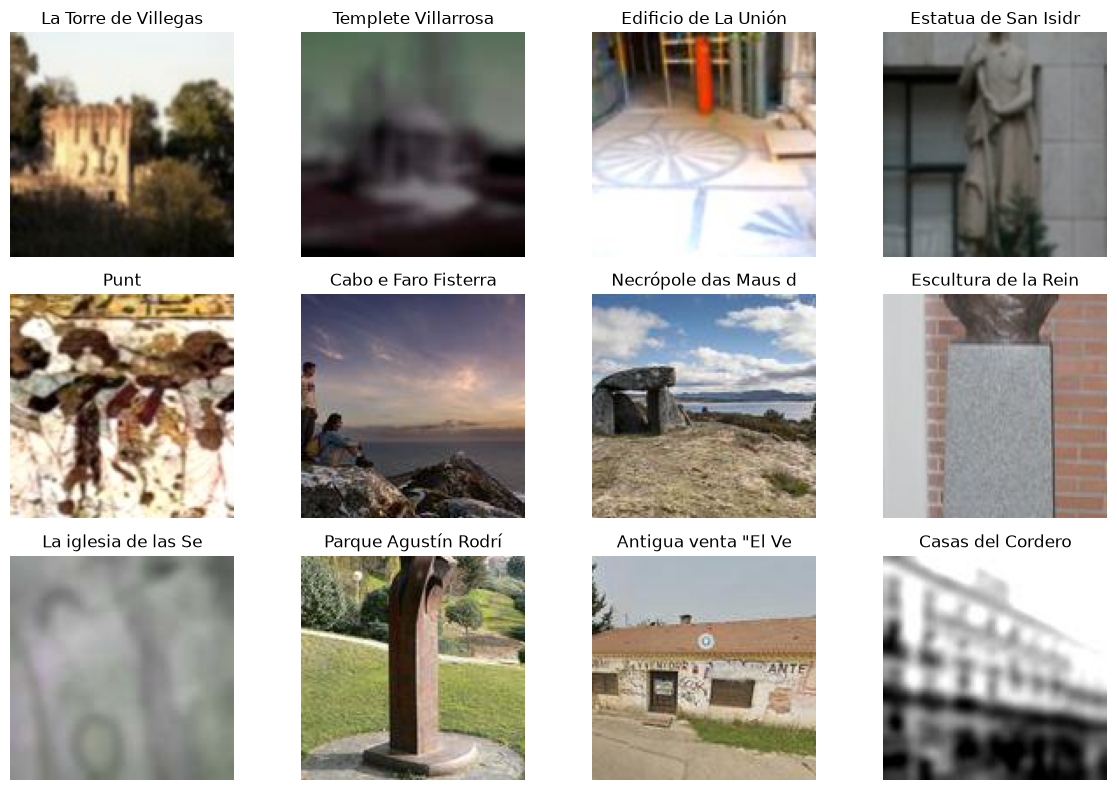

In [5]:
# ============================================================
# 5. Visualización de imágenes de ejemplo
# ============================================================

sample_df = df[df["image_exists"]].sample(
    n=min(12, df["image_exists"].sum()),
    random_state=RANDOM_SEED
)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["image_path_local"]).convert("RGB")
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(row["name"][:20])

plt.tight_layout()
plt.show()

## 4. Limpieza del dataset y control de duplicados

### Descripción

En esta sección se revisa si existen identificadores de POI repetidos. El dataset original contiene más filas que POIs únicos, por lo que algunos puntos de interés aparecen más de una vez.

### Decisión de limpieza

Se construye un dataset a nivel de POI único. Las variables estables se conservan tomando el primer valor, mientras que las métricas de interacción se agregan mediante promedio.

### Punto clave

Esta limpieza permite trabajar con un único registro por punto de interés y evita que una misma imagen pueda aparecer en diferentes subconjuntos del experimento.

In [6]:
# ============================================================
# 6. Parseo de columnas tipo lista
# ============================================================

def parse_list_column(value):
    """
    Convierte strings tipo "['Cultura', 'Historia']" en listas reales de Python.
    Si el valor está vacío o no se puede parsear, devuelve una lista vacía.
    """
    if isinstance(value, list):
        return value
    
    if pd.isna(value):
        return []
    
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return parsed
        return []
    except Exception:
        return []


df["categories_list"] = df["categories"].apply(parse_list_column)
df["tags_list"] = df["tags"].apply(parse_list_column)

display(df[["id", "categories", "categories_list", "tags", "tags_list"]].head())

,id,categories,categories_list,tags,tags_list
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,"['Escultura', 'Pintura']","[Escultura, Pintura]",[],[]
1,e32b3603-a94f-49df-8b31-92445a86377c,"['Patrimonio', 'Historia']","[Patrimonio, Historia]",[],[]
2,0123a69b-13ac-4b65-a5d5-71a95560cff5,"['Ciencia', 'Patrimonio']","[Ciencia, Patrimonio]",[],[]
3,390d7d9e-e972-451c-b5e4-f494af15e788,['Cultura'],[Cultura],[],[]
4,023fc1bf-a1cd-4b9f-af78-48792ab1a294,"['Patrimonio', 'Cultura']","[Patrimonio, Cultura]",[],[]


In [7]:
# ============================================================
# 7. Revisión de duplicados por POI
# ============================================================

num_rows = len(df)
num_unique_ids = df["id"].nunique()
num_duplicated_rows = df["id"].duplicated().sum()

print("Filas totales:", num_rows)
print("IDs únicos:", num_unique_ids)
print("Filas duplicadas por id:", num_duplicated_rows)

duplicated_ids = df.loc[df["id"].duplicated(keep=False), "id"].unique()

print("Número de IDs que aparecen más de una vez:", len(duplicated_ids))

display(
    df[df["id"].isin(duplicated_ids)]
    .sort_values("id")
    .head(12)
)

Filas totales: 1569
IDs únicos: 1492
Filas duplicadas por id: 77
Número de IDs que aparecen más de una vez: 23


,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path,image_path_local,image_exists,categories_list,tags_list
1178,04be145b-f73e-41aa-9332-d1702684dc53,El bosque de Dartmoor,"Explora Dartmoor, el misterioso páramo que ins...","['Ocio', 'Historia', 'Cultura', 'Misterio']",1,-3.901605,50.580627,['Sherlock Holmes'],1000,10007,2676,1610,611,data_main/04be145b-f73e-41aa-9332-d1702684dc53...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Ocio, Historia, Cultura, Misterio]",[Sherlock Holmes]
1179,04be145b-f73e-41aa-9332-d1702684dc53,El bosque de Dartmoor,"Explora Dartmoor, el misterioso páramo que ins...","['Ocio', 'Historia', 'Cultura', 'Misterio']",1,-3.901605,50.580627,['Perro'],1000,10003,2388,1017,619,data_main/04be145b-f73e-41aa-9332-d1702684dc53...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Ocio, Historia, Cultura, Misterio]",[Perro]
1180,04be145b-f73e-41aa-9332-d1702684dc53,El bosque de Dartmoor,"Explora Dartmoor, el misterioso páramo que ins...","['Ocio', 'Historia', 'Cultura', 'Misterio']",1,-3.901605,50.580627,['Naturaleza'],1000,10006,2701,1018,594,data_main/04be145b-f73e-41aa-9332-d1702684dc53...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Ocio, Historia, Cultura, Misterio]",[Naturaleza]
1181,04be145b-f73e-41aa-9332-d1702684dc53,El bosque de Dartmoor,"Explora Dartmoor, el misterioso páramo que ins...","['Ocio', 'Historia', 'Cultura', 'Misterio']",1,-3.901605,50.580627,['Bestia'],1000,10008,2645,1287,775,data_main/04be145b-f73e-41aa-9332-d1702684dc53...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Ocio, Historia, Cultura, Misterio]",[Bestia]
1407,060c7567-ef4a-4f09-9607-a4e3c2d4ad5c,Londinum Mithraeum,¡Explora el Londinum Mithraeum! Descubre el mi...,"['Cultura', 'Patrimonio', 'Historia', 'Misterio']",1,-0.090630,51.512306,['Londinum'],1000,10027,858,2882,92,data_main/060c7567-ef4a-4f09-9607-a4e3c2d4ad5c...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Cultura, Patrimonio, Historia, Misterio]",[Londinum]
1406,060c7567-ef4a-4f09-9607-a4e3c2d4ad5c,Londinum Mithraeum,¡Explora el Londinum Mithraeum! Descubre el mi...,"['Cultura', 'Patrimonio', 'Historia', 'Misterio']",1,-0.090630,51.512306,['Mitra'],1000,10018,647,2675,100,data_main/060c7567-ef4a-4f09-9607-a4e3c2d4ad5c...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Cultura, Patrimonio, Historia, Misterio]",[Mitra]
1405,060c7567-ef4a-4f09-9607-a4e3c2d4ad5c,Londinum Mithraeum,¡Explora el Londinum Mithraeum! Descubre el mi...,"['Cultura', 'Patrimonio', 'Historia', 'Misterio']",1,-0.090630,51.512306,['Mitraísmo'],1000,10014,2102,1221,466,data_main/060c7567-ef4a-4f09-9607-a4e3c2d4ad5c...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Cultura, Patrimonio, Historia, Misterio]",[Mitraísmo]
1403,060c7567-ef4a-4f09-9607-a4e3c2d4ad5c,Londinum Mithraeum,¡Explora el Londinum Mithraeum! Descubre el mi...,"['Cultura', 'Patrimonio', 'Historia', 'Misterio']",1,-0.090630,51.512306,['Serapis'],1000,10007,625,2561,128,data_main/060c7567-ef4a-4f09-9607-a4e3c2d4ad5c...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Cultura, Patrimonio, Historia, Misterio]",[Serapis]
1402,060c7567-ef4a-4f09-9607-a4e3c2d4ad5c,Londinum Mithraeum,¡Explora el Londinum Mithraeum! Descubre el mi...,"['Cultura', 'Patrimonio', 'Historia', 'Misterio']",1,-0.090630,51.512306,['Yacimientos'],1000,10012,673,2761,132,data_main/060c7567-ef4a-4f09-9607-a4e3c2d4ad5c...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Cultura, Patrimonio, Historia, Misterio]",[Yacimientos]
1404,060c7567-ef4a-4f09-9607-a4e3c2d4ad5c,Londinum Mithraeum,¡Explora el Londinum Mithraeum! Descubre el mi...,"['Cultura', 'Patrimonio', 'Historia', 'Misterio']",1,-0.090630,51.512306,['Religiones mistéricas'],1000,10017,695,2839,108,data_main/060c7567-ef4a-4f09-9607-a4e3c2d4ad5c...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Cultura, Patrimonio, Historia, Misterio]",[Religiones mis

In [8]:
# ============================================================
# 8. Agregación a nivel de POI único
# ============================================================

def unique_sorted_list(list_of_lists):
    """
    Une varias listas, elimina elementos repetidos y devuelve una lista ordenada.
    """
    items = []
    
    for sublist in list_of_lists:
        if isinstance(sublist, list):
            items.extend(sublist)
    
    return sorted(list(set(items)))


agg_dict = {
    "name": "first",
    "shortDescription": "first",
    "tier": "first",
    "locationLon": "first",
    "locationLat": "first",
    "xps": "mean",
    "Visits": "mean",
    "Likes": "mean",
    "Dislikes": "mean",
    "Bookmarks": "mean",
    "main_image_path": "first",
    "image_path_local": "first",
    "image_exists": "first",
    "categories_list": unique_sorted_list,
    "tags_list": unique_sorted_list,
}

df_model = (
    df
    .groupby("id", as_index=False)
    .agg(agg_dict)
    .reset_index(drop=True)
)

print("Filas originales:", len(df))
print("Filas después de agregar por POI único:", len(df_model))
print("IDs únicos en df_model:", df_model["id"].nunique())
print("Duplicados por id en df_model:", df_model["id"].duplicated().sum())
print("Imágenes faltantes en df_model:", (~df_model["image_exists"]).sum())

display(df_model.head())

Filas originales: 1569
Filas después de agregar por POI único: 1492
IDs únicos en df_model: 1492
Duplicados por id en df_model: 0
Imágenes faltantes en df_model: 0


,id,name,shortDescription,tier,locationLon,locationLat,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path,image_path_local,image_exists,categories_list,tags_list
0,002b3c1f-37f0-4d36-84d4-2d7132f83fe7,Casa-Museo de la Inquisición de Garganta la Olla,¡Visita la Casa-Museo de la Inquisición! Un vi...,1,-5.776669,40.111279,1000.0,10010.0,865.0,3099.0,118.0,data_main/002b3c1f-37f0-4d36-84d4-2d7132f83fe7...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Cultura, Historia, Misterio, Patrimonio]","[Edificios, Inquisición, Instalación, Museos, ..."
1,005fe23a-7f9e-4a57-a24a-1e9a6f1c1702,Real Basílica de San Francisco el Grande,"La Real Basílica de San Francisco el Grande, j...",2,-3.714472,40.410457,250.0,10011.0,8384.0,136.0,2275.0,data_main/005fe23a-7f9e-4a57-a24a-1e9a6f1c1702...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Arquitectura, Patrimonio]",[s.XVIII]
2,00761a42-1b02-42f3-b2b2-211ffd985118,Puerta de Toledo,¡Visita la Puerta de Toledo! Un arco triunfal ...,1,-3.711620,40.406714,800.0,10006.0,8359.0,146.0,2151.0,data_main/00761a42-1b02-42f3-b2b2-211ffd985118...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Arquitectura, Cultura, Historia]","[Arco de triunfo, Arquitectura neoclásica, Cen..."
3,0089bb20-c132-496c-b215-1986fcfa9d4b,Cuesta de los ciegos,La Cuesta de los Ciegos es una escalera empedr...,3,-3.714567,40.412984,150.0,10007.0,8398.0,137.0,2487.0,data_main/0089bb20-c132-496c-b215-1986fcfa9d4b...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Arquitectura, Historia]",[]
4,00f483bf-a5a2-4009-bc67-b9f3f2e73488,Escultura de AENA,"Admira la Escultura AENA, un símbolo de modern...",2,-3.652625,40.450756,600.0,10010.0,353.0,3901.0,82.0,data_main/00f483bf-a5a2-4009-bc67-b9f3f2e73488...,E:\Local IA Projects\Audio Transcription\Subs\...,True,"[Arquitectura, Escultura, Historia]","[Aeronáutica, Arquitectura moderna, Arte, Ciud..."


## 5. Construcción de la variable objetivo de engagement

#### Descripción

En esta sección se construye una métrica sintética de engagement a partir de las variables de interacción disponibles. Como el dataset no incluye una etiqueta directa de éxito, se combinan distintas señales de interacción para obtener un solo valor numérico llamado `engagement_score`.

#### Variables utilizadas

La métrica combina cuatro señales principales:

| Variable | Interpretación | Uso dentro de la métrica |
|---|---|---|
| `Visits` | Nivel de exposición del POI | Se incluye con peso bajo |
| `Likes` | Valoración positiva del usuario | Se incluye con peso alto |
| `Bookmarks` | Interés explícito o intención de guardar el POI | Se incluye con peso alto |
| `Dislikes` | Valoración negativa del usuario | Se resta de la métrica |

#### Fórmula propuesta

**engagement_score** =  
`0.25 * log1p(Visits)`  
`+ 2.00 * log1p(Likes)`  
`+ 2.00 * log1p(Bookmarks)`  
`- 1.00 * log1p(Dislikes)`

#### Justificación

Se da mayor peso a `Likes` y `Bookmarks` porque representan señales positivas de interés. `Dislikes` se resta porque representa una señal negativa. `Visits` se incluye con menor peso porque presenta poca variabilidad en comparación con las demás métricas.

Se utiliza `log1p`, equivalente a `log(1 + x)`, para reducir el efecto de valores extremos y estabilizar las escalas antes de combinar las variables.

#### Resultado esperado

El resultado de esta sección es una nueva columna llamada `engagement_score`, que resume en un solo valor la interacción estimada de cada POI. Esta variable no se usa como entrada del modelo, sino como base para construir la etiqueta de clasificación en la siguiente sección.

,Visits,Likes,Dislikes,Bookmarks
count,1492.000000,1492.000000,1492.000000,1492.000000
mean,10011.913695,3587.443607,2555.199524,964.850286
std,5.421825,4784.020524,2231.401859,1448.093127
min,10001.000000,100.000000,52.000000,50.000000
25%,10008.000000,450.000000,956.250000,116.000000
50%,10011.000000,1282.500000,2734.000000,303.000000
75%,10015.000000,6467.750000,3424.000000,1264.500000
max,10038.000000,26425.000000,10999.000000,8157.000000


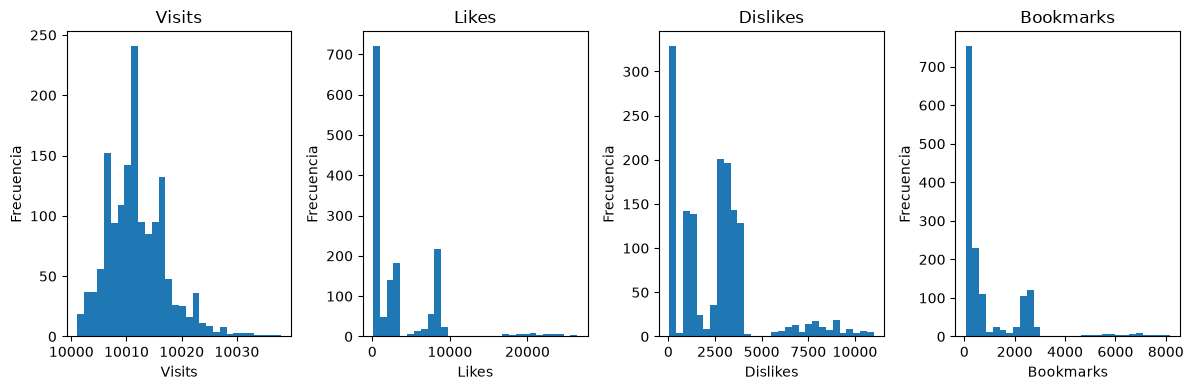

In [9]:
# ============================================================
# 9. Distribución de métricas originales de engagement
# ============================================================

engagement_cols = ["Visits", "Likes", "Dislikes", "Bookmarks"]

display(df_model[engagement_cols].describe())

plt.figure(figsize=(12, 4))

for i, col in enumerate(engagement_cols):
    plt.subplot(1, 4, i + 1)
    plt.hist(df_model[col], bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Resumen de engagement_score:


count    1492.000000
mean       21.582240
std         6.685949
min        11.541590
25%        15.979575
50%        18.891260
75%        26.410466
max        35.081538
Name: engagement_score, dtype: float64

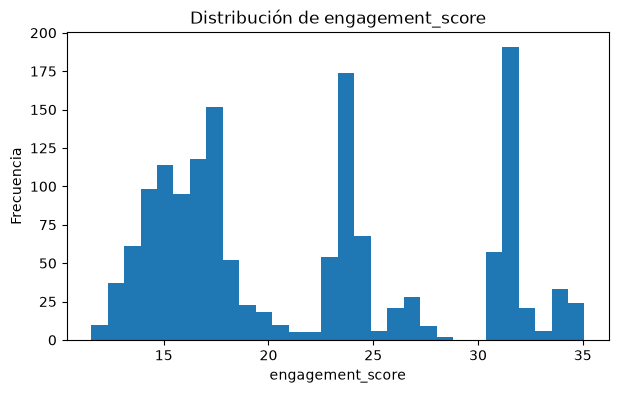

In [10]:
# ============================================================
# 10. Creación de engagement_score
# ============================================================

df_model["engagement_score"] = (
    0.25 * np.log1p(df_model["Visits"]) +
    2.00 * np.log1p(df_model["Likes"]) +
    2.00 * np.log1p(df_model["Bookmarks"]) -
    1.00 * np.log1p(df_model["Dislikes"])
)

print("Resumen de engagement_score:")
display(df_model["engagement_score"].describe())

plt.figure(figsize=(7, 4))
plt.hist(df_model["engagement_score"], bins=30)
plt.title("Distribución de engagement_score")
plt.xlabel("engagement_score")
plt.ylabel("Frecuencia")
plt.show()

## 6. Conversión a clasificación binaria

### Descripción

En esta sección se transforma el `engagement_score` en una etiqueta binaria.

### Criterio de clasificación

Se utiliza la mediana del `engagement_score` como umbral:

- `0`: engagement bajo
- `1`: engagement alto

### Punto clave

El uso de la mediana permite obtener dos clases balanceadas, lo cual facilita el entrenamiento y evita que el modelo favorezca una clase mayoritaria.

Umbral usado, mediana de engagement_score: 18.891259729103183

Distribución absoluta de clases:


engagement_label
0    746
1    746
Name: count, dtype: int64


Distribución porcentual de clases:


engagement_label
0    0.5
1    0.5
Name: proportion, dtype: float64

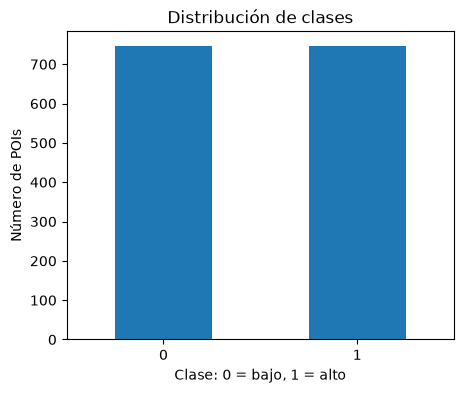

In [11]:
# ============================================================
# 11. Creación de etiqueta binaria
# ============================================================

threshold = df_model["engagement_score"].median()

df_model["engagement_label"] = (
    df_model["engagement_score"] >= threshold
).astype(int)

print("Umbral usado, mediana de engagement_score:", threshold)

print("\nDistribución absoluta de clases:")
display(df_model["engagement_label"].value_counts().sort_index())

print("\nDistribución porcentual de clases:")
display(df_model["engagement_label"].value_counts(normalize=True).sort_index())

plt.figure(figsize=(5, 4))
df_model["engagement_label"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Clase: 0 = bajo, 1 = alto")
plt.ylabel("Número de POIs")
plt.xticks(rotation=0)
plt.show()

In [12]:
# ============================================================
# 12. Ejemplos de POIs con bajo y alto engagement
# ============================================================

cols_to_show = [
    "id", "name", "Visits", "Likes", "Dislikes", "Bookmarks",
    "engagement_score", "engagement_label"
]

print("Ejemplos con engagement bajo:")
display(
    df_model
    .sort_values("engagement_score", ascending=True)
    [cols_to_show]
    .head(10)
)

print("\nEjemplos con engagement alto:")
display(
    df_model
    .sort_values("engagement_score", ascending=False)
    [cols_to_show]
    .head(10)
)

Ejemplos con engagement bajo:


,id,name,Visits,Likes,Dislikes,Bookmarks,engagement_score,engagement_label
1415,f6e9b1c3-632f-413a-bf8b-0d26bc402aa0,Estatua de Enrique Tierno Galván,10003.0,109.0,3428.0,53.0,11.541590,0
888,9974e7c7-6c13-4181-ac83-f48b4dddae79,El “Estilo Mucha” en el Casino de Madrid,10006.0,109.0,3705.0,63.0,11.803779,0
1299,e2553820-43dd-4f48-8bf4-a6e753b1e40e,Los toros de Guisando,10012.0,113.0,3761.0,63.0,11.860367,0
608,67b0ce15-3aa5-4f47-86f4-efcbbfdb85c4,Monumento a Velázquez,10018.0,104.0,3042.0,68.0,12.058594,0
1078,bbe4b672-340d-469b-9a0e-c1b867de7582,Monumento a Juan Santamaría,10011.0,126.0,3190.0,60.0,12.144917,0
980,aa4cafa3-1642-4abd-9850-fd6e8d646311,Monumento del Oso y el Madroño,10006.0,105.0,3164.0,74.0,12.204706,0
267,293f979b-a3b4-49c1-9fca-29bcea8a9ce8,Fuente con Escultura II en el Intercambiador d...,10010.0,161.0,3238.0,50.0,12.258684,0
103,114aefe5-4097-4ddf-bd4c-c67759f53458,El Vecino Curioso,10014.0,110.0,3465.0,76.0,12.258875,0
1482,ff6cd3f4-d16b-465f-974f-9637310ff423,Escultura La Vivienda,10005.0,123.0,3929.0,73.0,12.275034,0
279,2ae8b853-327c-4dfa-b759-3b4bdba5d69f,Icosaedro-Agua,10015.0,144.0,3873.0,62.0,12.280679,0



Ejemplos con engagement alto:


,id,name,Visits,Likes,Dislikes,Bookmarks,engagement_score,engagement_label
31,05756cfb-35a2-4214-a56c-0f9dde40687c,Restos mitraicos en el Museo Nacional de Hungría,10003.0,23719.0,205.0,7936.0,35.081538,1
708,7aa2036e-6bca-4b09-a297-a95db4f0eddc,O Cabo do Mundo,10010.0,24745.0,199.0,7476.0,35.076555,1
866,9592fcff-42a1-478d-acfb-dd9ac8202a6f,Monumento Puerta de la Latina,10003.0,20908.0,154.0,7704.0,35.054379,1
71,0bb262c6-24d2-4ba7-8ca5-75769aa8ba09,Necrópole das Maus de Salas,10006.0,26084.0,162.0,6171.0,35.002798,1
1474,fee3d22f-d8d6-4b46-a4b6-6bb6f6bf5531,Monumento de las Rejas del Arroyo Meaques,10009.0,18106.0,146.0,8043.0,34.905874,1
383,415782a8-5bae-4950-849d-db442d602379,Victoria Kent,10016.0,20614.0,180.0,7765.0,34.887082,1
177,1d7cfd3c-04b1-428f-8ac3-5d0faa5303b5,Portosín,10028.0,21356.0,149.0,6647.0,34.835086,1
1145,c9f32f67-05d0-4a83-8834-e268ab5ad71a,Edificio Capitol,10015.0,21977.0,122.0,5679.0,34.775808,1
230,2408cb71-840d-4bb7-b3b8-f59d24caf132,El Mitra de Cabra,10017.0,23817.0,221.0,7014.0,34.768363,1
249,26abf2f5-2370-46e4-bbc2-05dc1124ab8c,Teatro Coliseo,10006.0,21181.0,153.0,6555.0,34.763893,1


In [13]:
# ============================================================
# 13. Guardado del dataset limpio
# ============================================================

processed_path = OUTPUTS_DIR / "poi_dataset_model_ready.csv"

df_model.to_csv(processed_path, index=False)

print("Dataset limpio guardado en:")
print(processed_path)
print("Existe:", processed_path.exists())

Dataset limpio guardado en:
E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final\outputs\poi_dataset_model_ready.csv
Existe: True


## 7. Preparación de metadatos

### Descripción

En esta sección se preparan las variables estructuradas que serán utilizadas como entrada por los modelos basados en metadatos.

### Variables consideradas

Se utilizan variables numéricas como:

- `locationLon`
- `locationLat`
- `xps`
- número de categorías
- número de tags

También se codifican las categorías mediante una representación multi-hot.

### Variables excluidas

No se usan como entrada:

- `Visits`
- `Likes`
- `Dislikes`
- `Bookmarks`
- `engagement_score`

Estas variables no se incluyen porque fueron utilizadas para construir la etiqueta objetivo.

In [14]:
# ============================================================
# 14. Creación de variables simples de metadatos
# ============================================================

df_model["num_categories"] = df_model["categories_list"].apply(len)
df_model["num_tags"] = df_model["tags_list"].apply(len)

metadata_base_cols = [
    "locationLon",
    "locationLat",
    "xps",
    "num_categories",
    "num_tags",
]

print("Columnas numéricas base para metadatos:")
print(metadata_base_cols)

display(df_model[["id", "name", "categories_list", "tags_list"] + metadata_base_cols].head())

Columnas numéricas base para metadatos:
['locationLon', 'locationLat', 'xps', 'num_categories', 'num_tags']


,id,name,categories_list,tags_list,locationLon,locationLat,xps,num_categories,num_tags
0,002b3c1f-37f0-4d36-84d4-2d7132f83fe7,Casa-Museo de la Inquisición de Garganta la Olla,"[Cultura, Historia, Misterio, Patrimonio]","[Edificios, Inquisición, Instalación, Museos, ...",-5.776669,40.111279,1000.0,4,5
1,005fe23a-7f9e-4a57-a24a-1e9a6f1c1702,Real Basílica de San Francisco el Grande,"[Arquitectura, Patrimonio]",[s.XVIII],-3.714472,40.410457,250.0,2,1
2,00761a42-1b02-42f3-b2b2-211ffd985118,Puerta de Toledo,"[Arquitectura, Cultura, Historia]","[Arco de triunfo, Arquitectura neoclásica, Cen...",-3.711620,40.406714,800.0,3,13
3,0089bb20-c132-496c-b215-1986fcfa9d4b,Cuesta de los ciegos,"[Arquitectura, Historia]",[],-3.714567,40.412984,150.0,2,0
4,00f483bf-a5a2-4009-bc67-b9f3f2e73488,Escultura de AENA,"[Arquitectura, Escultura, Historia]","[Aeronáutica, Arquitectura moderna, Arte, Ciud...",-3.652625,40.450756,600.0,3,13


Número de categorías únicas: 12


Historia        1230
Cultura          958
Arquitectura     643
Patrimonio       574
Escultura        474
Misterio         311
Ciencia          123
Ocio              73
Pintura           47
Naturaleza        43
Cine              19
Gastronomía       18
Name: count, dtype: int64

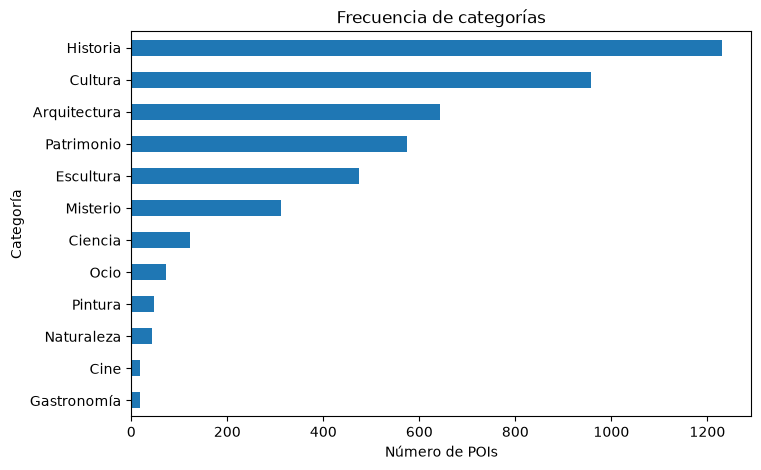

In [15]:
# ============================================================
# 15. Exploración de categorías
# ============================================================

all_categories = []

for categories in df_model["categories_list"]:
    all_categories.extend(categories)

category_counts = pd.Series(all_categories).value_counts()

print("Número de categorías únicas:", category_counts.shape[0])

display(category_counts)

plt.figure(figsize=(8, 5))
category_counts.sort_values().plot(kind="barh")
plt.title("Frecuencia de categorías")
plt.xlabel("Número de POIs")
plt.ylabel("Categoría")
plt.show()

## 8. División train / validation / test

### Descripción

En esta sección se divide el dataset en tres subconjuntos: entrenamiento, validación y prueba.

### Función de cada subconjunto

- **Train**: se utiliza para ajustar los pesos del modelo.
- **Validation**: se utiliza para comparar modelos durante el desarrollo.
- **Test**: se reserva para la evaluación final con datos no vistos.

### Punto clave

La división se realiza de forma estratificada usando `engagement_label`, para conservar proporciones similares de ambas clases en cada subconjunto.

In [16]:
# ============================================================
# 16. División estratificada train / validation / test
# ============================================================

from sklearn.model_selection import train_test_split

# Primero separamos test + validation como un bloque temporal
train_df, temp_df = train_test_split(
    df_model,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=df_model["engagement_label"]
)

# Luego dividimos el bloque temporal en validation y test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df["engagement_label"]
)

# Reiniciamos índices para evitar problemas posteriores en Dataset/DataLoader
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Tamaño train:", train_df.shape)
print("Tamaño validation:", val_df.shape)
print("Tamaño test:", test_df.shape)

print("\nDistribución de clases en train:")
display(train_df["engagement_label"].value_counts(normalize=True).sort_index())

print("\nDistribución de clases en validation:")
display(val_df["engagement_label"].value_counts(normalize=True).sort_index())

print("\nDistribución de clases en test:")
display(test_df["engagement_label"].value_counts(normalize=True).sort_index())

Tamaño train: (1044, 20)
Tamaño validation: (224, 20)
Tamaño test: (224, 20)

Distribución de clases en train:


engagement_label
0    0.5
1    0.5
Name: proportion, dtype: float64


Distribución de clases en validation:


engagement_label
0    0.5
1    0.5
Name: proportion, dtype: float64


Distribución de clases en test:


engagement_label
0    0.5
1    0.5
Name: proportion, dtype: float64

In [17]:
# ============================================================
# 17. Escalado de metadatos y codificación de categorías
# ============================================================

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer

# ------------------------------------------------------------
# Escalado de variables numéricas
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_num = scaler.fit_transform(train_df[metadata_base_cols])
X_val_num = scaler.transform(val_df[metadata_base_cols])
X_test_num = scaler.transform(test_df[metadata_base_cols])

# ------------------------------------------------------------
# Codificación multi-hot de categorías
# ------------------------------------------------------------

category_encoder = MultiLabelBinarizer()

X_train_cat = category_encoder.fit_transform(train_df["categories_list"])
X_val_cat = category_encoder.transform(val_df["categories_list"])
X_test_cat = category_encoder.transform(test_df["categories_list"])

print("Variables numéricas:", X_train_num.shape)
print("Categorías codificadas:", X_train_cat.shape)

print("\nCategorías aprendidas por el encoder:")
print(category_encoder.classes_)

Variables numéricas: (1044, 5)
Categorías codificadas: (1044, 12)

Categorías aprendidas por el encoder:
['Arquitectura' 'Ciencia' 'Cine' 'Cultura' 'Escultura' 'Gastronomía'
 'Historia' 'Misterio' 'Naturaleza' 'Ocio' 'Patrimonio' 'Pintura']


In [18]:
# ============================================================
# 18. Construcción de matrices finales de metadatos
# ============================================================

X_train_meta = np.concatenate([X_train_num, X_train_cat], axis=1)
X_val_meta = np.concatenate([X_val_num, X_val_cat], axis=1)
X_test_meta = np.concatenate([X_test_num, X_test_cat], axis=1)

y_train = train_df["engagement_label"].values
y_val = val_df["engagement_label"].values
y_test = test_df["engagement_label"].values

print("X_train_meta:", X_train_meta.shape)
print("X_val_meta:", X_val_meta.shape)
print("X_test_meta:", X_test_meta.shape)

print("\ny_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train_meta: (1044, 17)
X_val_meta: (224, 17)
X_test_meta: (224, 17)

y_train: (1044,)
y_val: (224,)
y_test: (224,)


In [19]:
# ============================================================
# 19. Guardado de splits procesados
# ============================================================

train_df.to_csv(OUTPUTS_DIR / "train_split.csv", index=False)
val_df.to_csv(OUTPUTS_DIR / "val_split.csv", index=False)
test_df.to_csv(OUTPUTS_DIR / "test_split.csv", index=False)

np.save(OUTPUTS_DIR / "X_train_meta.npy", X_train_meta)
np.save(OUTPUTS_DIR / "X_val_meta.npy", X_val_meta)
np.save(OUTPUTS_DIR / "X_test_meta.npy", X_test_meta)

np.save(OUTPUTS_DIR / "y_train.npy", y_train)
np.save(OUTPUTS_DIR / "y_val.npy", y_val)
np.save(OUTPUTS_DIR / "y_test.npy", y_test)

print("Archivos guardados en:", OUTPUTS_DIR)

Archivos guardados en: E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final\outputs


## 9. Dataset y DataLoader de PyTorch

### Descripción

En esta sección se construye un `Dataset` personalizado de PyTorch. Este objeto permite cargar, para cada POI, la imagen, los metadatos y la etiqueta correspondiente.

### Transformaciones

Las imágenes se redimensionan, se convierten a tensores y se normalizan. En el conjunto de entrenamiento se aplica una transformación básica de aumento de datos.

### Punto clave

Los `DataLoader` permiten alimentar los modelos por batches, lo cual hace el entrenamiento más eficiente y compatible con GPU.

In [20]:
# ============================================================
# 20. Imports para Dataset y DataLoader
# ============================================================

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [21]:
# ============================================================
# 21. Transformaciones para imágenes
# ============================================================

IMAGE_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [22]:
# ============================================================
# 22. Dataset personalizado
# ============================================================

class POIDataset(Dataset):
    def __init__(self, dataframe, metadata_array, labels, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.metadata_array = metadata_array.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        image_path = row["image_path_local"]
        image = Image.open(image_path).convert("RGB")
        
        if self.transform is not None:
            image = self.transform(image)
        
        metadata = torch.tensor(self.metadata_array[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return {
            "image": image,
            "metadata": metadata,
            "label": label
        }

In [23]:
# ============================================================
# 23. Creación de datasets
# ============================================================

train_dataset = POIDataset(
    dataframe=train_df,
    metadata_array=X_train_meta,
    labels=y_train,
    transform=train_transform
)

val_dataset = POIDataset(
    dataframe=val_df,
    metadata_array=X_val_meta,
    labels=y_val,
    transform=eval_transform
)

test_dataset = POIDataset(
    dataframe=test_df,
    metadata_array=X_test_meta,
    labels=y_test,
    transform=eval_transform
)

print("Tamaño train_dataset:", len(train_dataset))
print("Tamaño val_dataset:", len(val_dataset))
print("Tamaño test_dataset:", len(test_dataset))

Tamaño train_dataset: 1044
Tamaño val_dataset: 224
Tamaño test_dataset: 224


In [24]:
# ============================================================
# 24. Creación de DataLoaders
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Número de batches train:", len(train_loader))
print("Número de batches validation:", len(val_loader))
print("Número de batches test:", len(test_loader))

Número de batches train: 33
Número de batches validation: 7
Número de batches test: 7


In [25]:
# ============================================================
# 25. Verificación de un batch
# ============================================================

batch = next(iter(train_loader))

images = batch["image"]
metadata = batch["metadata"]
labels = batch["label"]

print("Shape imágenes:", images.shape)
print("Shape metadatos:", metadata.shape)
print("Shape labels:", labels.shape)

print("\nTipo imágenes:", images.dtype)
print("Tipo metadatos:", metadata.dtype)
print("Tipo labels:", labels.dtype)

print("\nMínimo imagen:", images.min().item())
print("Máximo imagen:", images.max().item())

Shape imágenes: torch.Size([32, 3, 128, 128])
Shape metadatos: torch.Size([32, 17])
Shape labels: torch.Size([32])

Tipo imágenes: torch.float32
Tipo metadatos: torch.float32
Tipo labels: torch.int64

Mínimo imagen: -1.0
Máximo imagen: 1.0


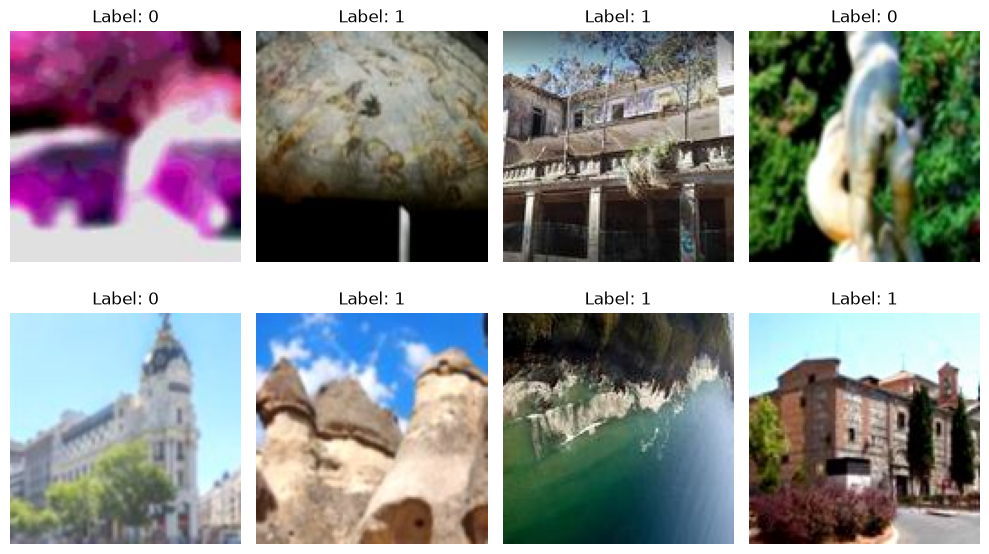

In [26]:
# ============================================================
# 26. Visualización de imágenes transformadas
# ============================================================

def unnormalize_image(tensor_image):
    image = tensor_image.clone()
    image = image * 0.5 + 0.5
    image = image.permute(1, 2, 0)
    image = image.numpy()
    image = np.clip(image, 0, 1)
    return image


plt.figure(figsize=(10, 6))

for i in range(8):
    img = unnormalize_image(images[i])
    label = labels[i].item()
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {label}")

plt.tight_layout()
plt.show()

## 10. Modelo baseline

### Descripción

En esta sección se implementa un modelo de referencia basado en la clase mayoritaria.

### Propósito

El baseline sirve como punto mínimo de comparación. Si un modelo neuronal no supera este resultado, entonces no estaría aprovechando adecuadamente la información disponible.

### Punto clave

Como las clases están balanceadas, se espera que el baseline tenga un rendimiento cercano a 0.50 en accuracy.

In [27]:
# ============================================================
# 27. Baseline de clase mayoritaria
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

majority_class = pd.Series(y_train).mode()[0]

baseline_val_preds = np.full_like(y_val, fill_value=majority_class)
baseline_test_preds = np.full_like(y_test, fill_value=majority_class)

print("Clase mayoritaria en train:", majority_class)

print("\nBaseline en validation:")
print("Accuracy:", accuracy_score(y_val, baseline_val_preds))
print("Precision:", precision_score(y_val, baseline_val_preds, zero_division=0))
print("Recall:", recall_score(y_val, baseline_val_preds, zero_division=0))
print("F1:", f1_score(y_val, baseline_val_preds, zero_division=0))

print("\nBaseline en test:")
print("Accuracy:", accuracy_score(y_test, baseline_test_preds))
print("Precision:", precision_score(y_test, baseline_test_preds, zero_division=0))
print("Recall:", recall_score(y_test, baseline_test_preds, zero_division=0))
print("F1:", f1_score(y_test, baseline_test_preds, zero_division=0))

print("\nClassification report en test:")
print(classification_report(y_test, baseline_test_preds, zero_division=0))

Clase mayoritaria en train: 0

Baseline en validation:
Accuracy: 0.5
Precision: 0.0
Recall: 0.0
F1: 0.0

Baseline en test:
Accuracy: 0.5
Precision: 0.0
Recall: 0.0
F1: 0.0

Classification report en test:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       112
           1       0.00      0.00      0.00       112

    accuracy                           0.50       224
   macro avg       0.25      0.50      0.33       224
weighted avg       0.25      0.50      0.33       224



## 11. Modelo solo metadatos

### Descripción

En esta sección se entrena una red fully connected usando únicamente los metadatos procesados.

### Objetivo

Este modelo permite evaluar cuánto aportan las variables estructuradas al problema de clasificación, sin utilizar información visual.

### Análisis esperado

Si el modelo obtiene buen rendimiento, significa que variables como ubicación, categorías, experiencia y conteos derivados contienen señales útiles para estimar el engagement.

In [28]:
# ============================================================
# 28. Imports para modelos
# ============================================================

import torch.nn as nn
import torch.optim as optim

In [29]:
# ============================================================
# 29. Modelo MLP para metadatos
# ============================================================

class MetadataMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_classes=2):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            
            nn.Linear(hidden_dim // 2, num_classes)
        )
    
    def forward(self, metadata):
        return self.network(metadata)


metadata_input_dim = X_train_meta.shape[1]

metadata_model = MetadataMLP(
    input_dim=metadata_input_dim,
    hidden_dim=64,
    num_classes=2
).to(device)

print(metadata_model)
print("\nNúmero de features de entrada:", metadata_input_dim)

MetadataMLP(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)

Número de features de entrada: 17


In [30]:
# ============================================================
# 30. Funciones de entrenamiento y evaluación para metadatos
# ============================================================

def train_one_epoch_metadata(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch in dataloader:
        metadata = batch["metadata"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(metadata)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * labels.size(0)
        
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def evaluate_metadata(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for batch in dataloader:
            metadata = batch["metadata"].to(device)
            labels = batch["label"].to(device)
            
            outputs = model(metadata)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * labels.size(0)
            
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [31]:
# ============================================================
# 31. Entrenamiento del modelo solo metadatos
# ============================================================

import copy

metadata_model = MetadataMLP(
    input_dim=metadata_input_dim,
    hidden_dim=64,
    num_classes=2
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    metadata_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

NUM_EPOCHS = 30

history_metadata = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
best_metadata_state = None
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch_metadata(
        metadata_model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss, val_acc, _, _ = evaluate_metadata(
        metadata_model,
        val_loader,
        criterion,
        device
    )
    
    history_metadata["train_loss"].append(train_loss)
    history_metadata["train_acc"].append(train_acc)
    history_metadata["val_loss"].append(val_loss)
    history_metadata["val_acc"].append(val_acc)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_metadata_state = copy.deepcopy(metadata_model.state_dict())
        best_epoch = epoch + 1
    
    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

metadata_model.load_state_dict(best_metadata_state)

print("\nMejor epoch:", best_epoch)
print("Mejor validation loss:", best_val_loss)

Epoch [01/30] Train Loss: 0.6602 | Train Acc: 0.6648 | Val Loss: 0.6013 | Val Acc: 0.7812
Epoch [02/30] Train Loss: 0.5872 | Train Acc: 0.7136 | Val Loss: 0.4847 | Val Acc: 0.7991
Epoch [03/30] Train Loss: 0.5103 | Train Acc: 0.7557 | Val Loss: 0.4136 | Val Acc: 0.8125
Epoch [04/30] Train Loss: 0.4795 | Train Acc: 0.7730 | Val Loss: 0.3863 | Val Acc: 0.8482
Epoch [05/30] Train Loss: 0.4531 | Train Acc: 0.7912 | Val Loss: 0.3707 | Val Acc: 0.8571
Epoch [06/30] Train Loss: 0.4388 | Train Acc: 0.7941 | Val Loss: 0.3752 | Val Acc: 0.8527
Epoch [07/30] Train Loss: 0.4410 | Train Acc: 0.7960 | Val Loss: 0.3662 | Val Acc: 0.8527
Epoch [08/30] Train Loss: 0.4352 | Train Acc: 0.8046 | Val Loss: 0.3697 | Val Acc: 0.8527
Epoch [09/30] Train Loss: 0.4321 | Train Acc: 0.7979 | Val Loss: 0.3653 | Val Acc: 0.8527
Epoch [10/30] Train Loss: 0.4315 | Train Acc: 0.7989 | Val Loss: 0.3629 | Val Acc: 0.8527
Epoch [11/30] Train Loss: 0.4311 | Train Acc: 0.8065 | Val Loss: 0.3614 | Val Acc: 0.8527
Epoch [12/

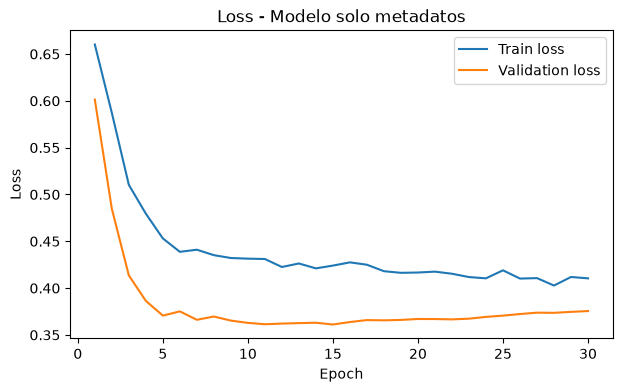

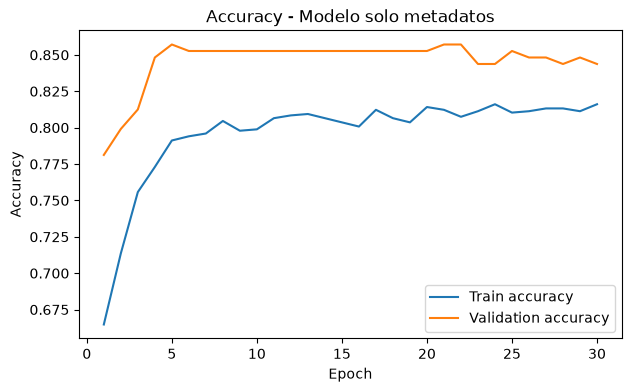

In [32]:
# ============================================================
# 32. Curvas de entrenamiento del modelo de metadatos
# ============================================================

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, history_metadata["train_loss"], label="Train loss")
plt.plot(epochs, history_metadata["val_loss"], label="Validation loss")
plt.title("Loss - Modelo solo metadatos")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history_metadata["train_acc"], label="Train accuracy")
plt.plot(epochs, history_metadata["val_acc"], label="Validation accuracy")
plt.title("Accuracy - Modelo solo metadatos")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [33]:
# ============================================================
# 33. Evaluación final del modelo solo metadatos
# ============================================================

val_loss, val_acc, val_labels, val_preds = evaluate_metadata(
    metadata_model,
    val_loader,
    criterion,
    device
)

test_loss, test_acc, test_labels, test_preds = evaluate_metadata(
    metadata_model,
    test_loader,
    criterion,
    device
)

print("Resultados en validation:")
print("Loss:", val_loss)
print("Accuracy:", val_acc)
print("Precision:", precision_score(val_labels, val_preds, zero_division=0))
print("Recall:", recall_score(val_labels, val_preds, zero_division=0))
print("F1:", f1_score(val_labels, val_preds, zero_division=0))

print("\nResultados en test:")
print("Loss:", test_loss)
print("Accuracy:", test_acc)
print("Precision:", precision_score(test_labels, test_preds, zero_division=0))
print("Recall:", recall_score(test_labels, test_preds, zero_division=0))
print("F1:", f1_score(test_labels, test_preds, zero_division=0))

print("\nClassification report en test:")
print(classification_report(test_labels, test_preds, zero_division=0))

Resultados en validation:
Loss: 0.36115660624844687
Accuracy: 0.8526785714285714
Precision: 0.7724137931034483
Recall: 1.0
F1: 0.8715953307392996

Resultados en test:
Loss: 0.43839743733406067
Accuracy: 0.7991071428571429
Precision: 0.7189542483660131
Recall: 0.9821428571428571
F1: 0.8301886792452831

Classification report en test:
              precision    recall  f1-score   support

           0       0.97      0.62      0.75       112
           1       0.72      0.98      0.83       112

    accuracy                           0.80       224
   macro avg       0.85      0.80      0.79       224
weighted avg       0.85      0.80      0.79       224



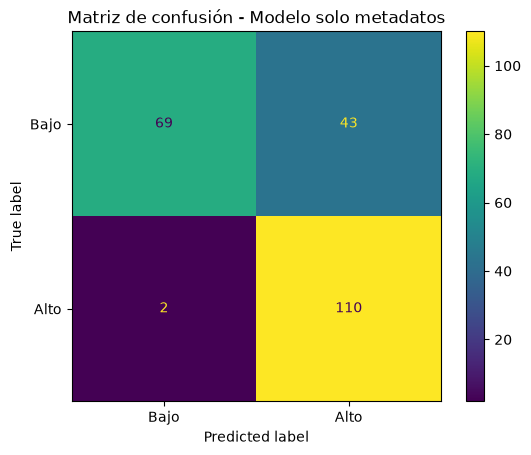

In [34]:
# ============================================================
# 34. Matriz de confusión del modelo solo metadatos
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Bajo", "Alto"]
)

disp.plot()
plt.title("Matriz de confusión - Modelo solo metadatos")
plt.show()

## 12. Modelo solo imágenes CNN

### Descripción

En esta sección se entrena una red convolucional usando únicamente las imágenes de los POIs.

### Objetivo

Este modelo permite medir el aporte de la información visual al problema de clasificación.

### Análisis esperado

La CNN aprende patrones visuales generales a partir de las imágenes. Su rendimiento permite evaluar si la imagen por sí sola contiene suficiente información para predecir engagement alto o bajo.

In [35]:
# ============================================================
# 35. Modelo CNN para imágenes
# ============================================================

class ImageCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, image):
        x = self.features(image)
        x = self.classifier(x)
        return x


image_model = ImageCNN(num_classes=2).to(device)

print(image_model)

ImageCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=Tr

In [36]:
# ============================================================
# 36. Funciones de entrenamiento y evaluación para imágenes
# ============================================================

def train_one_epoch_image(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch in dataloader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * labels.size(0)
        
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def evaluate_image(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * labels.size(0)
            
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [37]:
# ============================================================
# 37. Entrenamiento del modelo solo imágenes
# ============================================================

image_model = ImageCNN(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    image_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

NUM_EPOCHS_IMAGE = 30

history_image = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss_image = float("inf")
best_image_state = None
best_epoch_image = 0

for epoch in range(NUM_EPOCHS_IMAGE):
    train_loss, train_acc = train_one_epoch_image(
        image_model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss, val_acc, _, _ = evaluate_image(
        image_model,
        val_loader,
        criterion,
        device
    )
    
    history_image["train_loss"].append(train_loss)
    history_image["train_acc"].append(train_acc)
    history_image["val_loss"].append(val_loss)
    history_image["val_acc"].append(val_acc)
    
    if val_loss < best_val_loss_image:
        best_val_loss_image = val_loss
        best_image_state = copy.deepcopy(image_model.state_dict())
        best_epoch_image = epoch + 1
    
    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS_IMAGE}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

image_model.load_state_dict(best_image_state)

print("\nMejor epoch:", best_epoch_image)
print("Mejor validation loss:", best_val_loss_image)

Epoch [01/30] Train Loss: 0.6287 | Train Acc: 0.6542 | Val Loss: 0.6810 | Val Acc: 0.5670
Epoch [02/30] Train Loss: 0.5888 | Train Acc: 0.7011 | Val Loss: 0.5495 | Val Acc: 0.7321
Epoch [03/30] Train Loss: 0.5844 | Train Acc: 0.6964 | Val Loss: 0.5605 | Val Acc: 0.7321
Epoch [04/30] Train Loss: 0.5779 | Train Acc: 0.7222 | Val Loss: 0.5493 | Val Acc: 0.7411
Epoch [05/30] Train Loss: 0.5420 | Train Acc: 0.7366 | Val Loss: 0.5487 | Val Acc: 0.7455
Epoch [06/30] Train Loss: 0.5328 | Train Acc: 0.7404 | Val Loss: 0.5385 | Val Acc: 0.7411
Epoch [07/30] Train Loss: 0.5449 | Train Acc: 0.7356 | Val Loss: 0.5166 | Val Acc: 0.7679
Epoch [08/30] Train Loss: 0.5342 | Train Acc: 0.7500 | Val Loss: 0.5129 | Val Acc: 0.7321
Epoch [09/30] Train Loss: 0.5255 | Train Acc: 0.7452 | Val Loss: 0.5286 | Val Acc: 0.7545
Epoch [10/30] Train Loss: 0.5239 | Train Acc: 0.7577 | Val Loss: 0.5104 | Val Acc: 0.7902
Epoch [11/30] Train Loss: 0.5044 | Train Acc: 0.7672 | Val Loss: 0.5357 | Val Acc: 0.7455
Epoch [12/

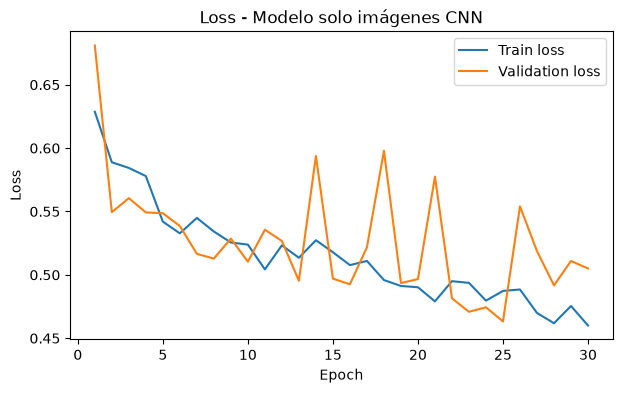

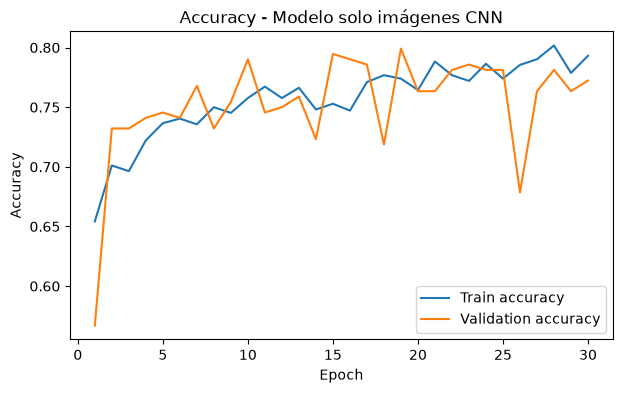

In [38]:
# ============================================================
# 38. Curvas de entrenamiento del modelo solo imágenes
# ============================================================

epochs_image = range(1, NUM_EPOCHS_IMAGE + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_image, history_image["train_loss"], label="Train loss")
plt.plot(epochs_image, history_image["val_loss"], label="Validation loss")
plt.title("Loss - Modelo solo imágenes CNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_image, history_image["train_acc"], label="Train accuracy")
plt.plot(epochs_image, history_image["val_acc"], label="Validation accuracy")
plt.title("Accuracy - Modelo solo imágenes CNN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [39]:
# ============================================================
# 39. Evaluación final del modelo solo imágenes
# ============================================================

val_loss_img, val_acc_img, val_labels_img, val_preds_img = evaluate_image(
    image_model,
    val_loader,
    criterion,
    device
)

test_loss_img, test_acc_img, test_labels_img, test_preds_img = evaluate_image(
    image_model,
    test_loader,
    criterion,
    device
)

print("Resultados en validation:")
print("Loss:", val_loss_img)
print("Accuracy:", val_acc_img)
print("Precision:", precision_score(val_labels_img, val_preds_img, zero_division=0))
print("Recall:", recall_score(val_labels_img, val_preds_img, zero_division=0))
print("F1:", f1_score(val_labels_img, val_preds_img, zero_division=0))

print("\nResultados en test:")
print("Loss:", test_loss_img)
print("Accuracy:", test_acc_img)
print("Precision:", precision_score(test_labels_img, test_preds_img, zero_division=0))
print("Recall:", recall_score(test_labels_img, test_preds_img, zero_division=0))
print("F1:", f1_score(test_labels_img, test_preds_img, zero_division=0))

print("\nClassification report en test:")
print(classification_report(test_labels_img, test_preds_img, zero_division=0))

Resultados en validation:
Loss: 0.46326604059764315
Accuracy: 0.78125
Precision: 0.7480314960629921
Recall: 0.8482142857142857
F1: 0.7949790794979079

Resultados en test:
Loss: 0.5410568884440831
Accuracy: 0.7589285714285714
Precision: 0.7543859649122807
Recall: 0.7678571428571429
F1: 0.7610619469026548

Classification report en test:
              precision    recall  f1-score   support

           0       0.76      0.75      0.76       112
           1       0.75      0.77      0.76       112

    accuracy                           0.76       224
   macro avg       0.76      0.76      0.76       224
weighted avg       0.76      0.76      0.76       224



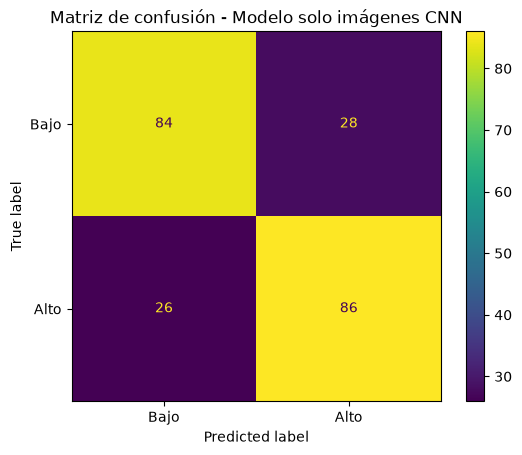

In [40]:
# ============================================================
# 40. Matriz de confusión del modelo solo imágenes
# ============================================================

cm_img = confusion_matrix(test_labels_img, test_preds_img)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_img,
    display_labels=["Bajo", "Alto"]
)

disp.plot()
plt.title("Matriz de confusión - Modelo solo imágenes CNN")
plt.show()

## 13. Modelo híbrido CNN + metadatos

### Descripción

En esta sección se construye el modelo principal del proyecto. La arquitectura combina una rama convolucional para imágenes y una rama fully connected para metadatos.

### Estructura del modelo

La rama visual extrae una representación de la imagen del POI. La rama de metadatos aprende una representación a partir de las variables estructuradas. Después, ambas representaciones se concatenan y se pasan a un clasificador final.

### Punto clave

Este enfoque permite combinar información visual y contextual en una sola predicción.

In [41]:
# ============================================================
# 42. Modelo híbrido CNN + metadatos
# ============================================================

class HybridCNNMetadata(nn.Module):
    def __init__(self, metadata_input_dim, num_classes=2):
        super().__init__()
        
        # Rama CNN para imágenes
        self.image_features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.image_projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3)
        )
        
        # Rama MLP para metadatos
        self.metadata_projection = nn.Sequential(
            nn.Linear(metadata_input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2)
        )
        
        # Clasificador final después de concatenar imagen + metadatos
        self.classifier = nn.Sequential(
            nn.Linear(64 + 32, 64),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, num_classes)
        )
    
    def forward(self, image, metadata):
        image_features = self.image_features(image)
        image_features = self.image_projection(image_features)
        
        metadata_features = self.metadata_projection(metadata)
        
        combined_features = torch.cat(
            [image_features, metadata_features],
            dim=1
        )
        
        output = self.classifier(combined_features)
        
        return output


hybrid_model = HybridCNNMetadata(
    metadata_input_dim=metadata_input_dim,
    num_classes=2
).to(device)

print(hybrid_model)

HybridCNNMetadata(
  (image_features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum

In [42]:
# ============================================================
# 43. Funciones de entrenamiento y evaluación para modelo híbrido
# ============================================================

def train_one_epoch_hybrid(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch in dataloader:
        images = batch["image"].to(device)
        metadata = batch["metadata"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images, metadata)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * labels.size(0)
        
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def evaluate_hybrid(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device)
            metadata = batch["metadata"].to(device)
            labels = batch["label"].to(device)
            
            outputs = model(images, metadata)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * labels.size(0)
            
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [43]:
# ============================================================
# 44. Entrenamiento del modelo híbrido
# ============================================================

hybrid_model = HybridCNNMetadata(
    metadata_input_dim=metadata_input_dim,
    num_classes=2
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    hybrid_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

NUM_EPOCHS_HYBRID = 30

history_hybrid = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss_hybrid = float("inf")
best_hybrid_state = None
best_epoch_hybrid = 0

for epoch in range(NUM_EPOCHS_HYBRID):
    train_loss, train_acc = train_one_epoch_hybrid(
        hybrid_model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss, val_acc, _, _ = evaluate_hybrid(
        hybrid_model,
        val_loader,
        criterion,
        device
    )
    
    history_hybrid["train_loss"].append(train_loss)
    history_hybrid["train_acc"].append(train_acc)
    history_hybrid["val_loss"].append(val_loss)
    history_hybrid["val_acc"].append(val_acc)
    
    if val_loss < best_val_loss_hybrid:
        best_val_loss_hybrid = val_loss
        best_hybrid_state = copy.deepcopy(hybrid_model.state_dict())
        best_epoch_hybrid = epoch + 1
    
    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS_HYBRID}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

hybrid_model.load_state_dict(best_hybrid_state)

print("\nMejor epoch:", best_epoch_hybrid)
print("Mejor validation loss:", best_val_loss_hybrid)

Epoch [01/30] Train Loss: 0.6598 | Train Acc: 0.6015 | Val Loss: 0.5967 | Val Acc: 0.7500
Epoch [02/30] Train Loss: 0.6010 | Train Acc: 0.6983 | Val Loss: 0.5002 | Val Acc: 0.7812
Epoch [03/30] Train Loss: 0.4563 | Train Acc: 0.8084 | Val Loss: 0.2923 | Val Acc: 0.8839
Epoch [04/30] Train Loss: 0.2922 | Train Acc: 0.8870 | Val Loss: 0.1960 | Val Acc: 0.9241
Epoch [05/30] Train Loss: 0.2602 | Train Acc: 0.9004 | Val Loss: 0.1683 | Val Acc: 0.9375
Epoch [06/30] Train Loss: 0.2146 | Train Acc: 0.9224 | Val Loss: 0.1771 | Val Acc: 0.9152
Epoch [07/30] Train Loss: 0.1906 | Train Acc: 0.9310 | Val Loss: 0.1719 | Val Acc: 0.9152
Epoch [08/30] Train Loss: 0.1881 | Train Acc: 0.9330 | Val Loss: 0.1682 | Val Acc: 0.9286
Epoch [09/30] Train Loss: 0.2044 | Train Acc: 0.9138 | Val Loss: 0.1579 | Val Acc: 0.9241
Epoch [10/30] Train Loss: 0.1938 | Train Acc: 0.9224 | Val Loss: 0.2174 | Val Acc: 0.8839
Epoch [11/30] Train Loss: 0.1688 | Train Acc: 0.9339 | Val Loss: 0.1870 | Val Acc: 0.9330
Epoch [12/

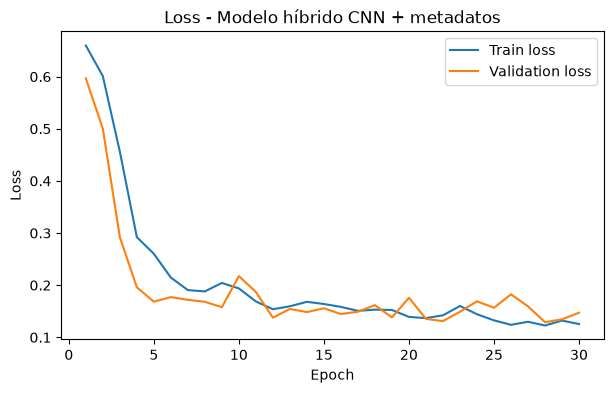

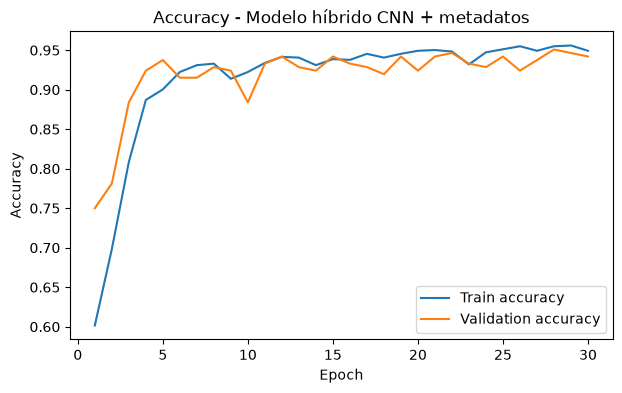

In [44]:
# ============================================================
# 45. Curvas de entrenamiento del modelo híbrido
# ============================================================

epochs_hybrid = range(1, NUM_EPOCHS_HYBRID + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_hybrid, history_hybrid["train_loss"], label="Train loss")
plt.plot(epochs_hybrid, history_hybrid["val_loss"], label="Validation loss")
plt.title("Loss - Modelo híbrido CNN + metadatos")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_hybrid, history_hybrid["train_acc"], label="Train accuracy")
plt.plot(epochs_hybrid, history_hybrid["val_acc"], label="Validation accuracy")
plt.title("Accuracy - Modelo híbrido CNN + metadatos")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [45]:
# ============================================================
# 46. Evaluación final del modelo híbrido
# ============================================================

val_loss_hybrid, val_acc_hybrid, val_labels_hybrid, val_preds_hybrid = evaluate_hybrid(
    hybrid_model,
    val_loader,
    criterion,
    device
)

test_loss_hybrid, test_acc_hybrid, test_labels_hybrid, test_preds_hybrid = evaluate_hybrid(
    hybrid_model,
    test_loader,
    criterion,
    device
)

print("Resultados en validation:")
print("Loss:", val_loss_hybrid)
print("Accuracy:", val_acc_hybrid)
print("Precision:", precision_score(val_labels_hybrid, val_preds_hybrid, zero_division=0))
print("Recall:", recall_score(val_labels_hybrid, val_preds_hybrid, zero_division=0))
print("F1:", f1_score(val_labels_hybrid, val_preds_hybrid, zero_division=0))

print("\nResultados en test:")
print("Loss:", test_loss_hybrid)
print("Accuracy:", test_acc_hybrid)
print("Precision:", precision_score(test_labels_hybrid, test_preds_hybrid, zero_division=0))
print("Recall:", recall_score(test_labels_hybrid, test_preds_hybrid, zero_division=0))
print("F1:", f1_score(test_labels_hybrid, test_preds_hybrid, zero_division=0))

print("\nClassification report en test:")
print(classification_report(test_labels_hybrid, test_preds_hybrid, zero_division=0))

Resultados en validation:
Loss: 0.12905297907335417
Accuracy: 0.9508928571428571
Precision: 1.0
Recall: 0.9017857142857143
F1: 0.9483568075117371

Resultados en test:
Loss: 0.19502960571220943
Accuracy: 0.9196428571428571
Precision: 1.0
Recall: 0.8392857142857143
F1: 0.912621359223301

Classification report en test:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       112
           1       1.00      0.84      0.91       112

    accuracy                           0.92       224
   macro avg       0.93      0.92      0.92       224
weighted avg       0.93      0.92      0.92       224



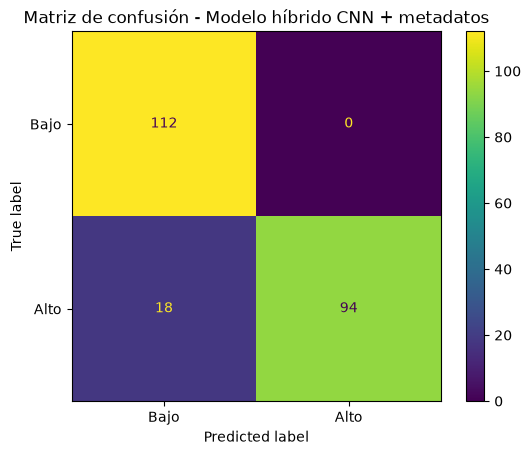

In [46]:
# ============================================================
# 47. Matriz de confusión del modelo híbrido
# ============================================================

cm_hybrid = confusion_matrix(test_labels_hybrid, test_preds_hybrid)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hybrid,
    display_labels=["Bajo", "Alto"]
)

disp.plot()
plt.title("Matriz de confusión - Modelo híbrido CNN + metadatos")
plt.show()

In [47]:
# ============================================================
# 48. Guardado del modelo híbrido
# ============================================================

hybrid_model_path = MODELS_DIR / "hybrid_cnn_metadata_model.pt"

torch.save(
    {
        "model_state_dict": hybrid_model.state_dict(),
        "best_epoch": best_epoch_hybrid,
        "best_val_loss": best_val_loss_hybrid,
        "metadata_input_dim": metadata_input_dim,
        "image_size": IMAGE_SIZE
    },
    hybrid_model_path
)

print("Modelo guardado en:")
print(hybrid_model_path)
print("Existe:", hybrid_model_path.exists())

Modelo guardado en:
E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final\models\hybrid_cnn_metadata_model.pt
Existe: True


,Modelo,Accuracy,Precision,Recall,F1
0,Baseline clase mayoritaria,0.500000,0.000000,0.000000,0.000000
1,Solo metadatos,0.799107,0.718954,0.982143,0.830189
2,Solo imágenes CNN,0.758929,0.754386,0.767857,0.761062
3,Híbrido CNN + metadatos,0.919643,1.000000,0.839286,0.912621


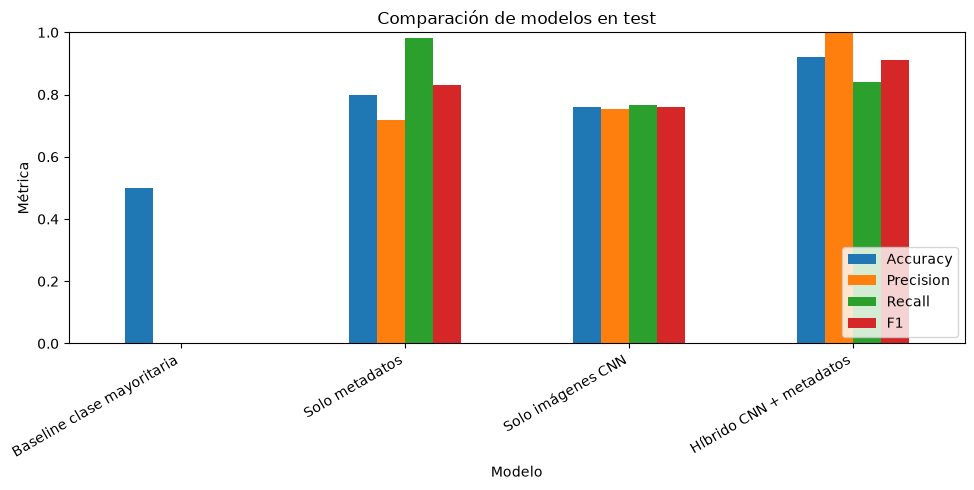

In [48]:
# ============================================================
# 49. Comparación general de modelos en test
# ============================================================

results_summary = pd.DataFrame({
    "Modelo": [
        "Baseline clase mayoritaria",
        "Solo metadatos",
        "Solo imágenes CNN",
        "Híbrido CNN + metadatos"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_test_preds),
        test_acc,
        test_acc_img,
        test_acc_hybrid
    ],
    "Precision": [
        precision_score(y_test, baseline_test_preds, zero_division=0),
        precision_score(test_labels, test_preds, zero_division=0),
        precision_score(test_labels_img, test_preds_img, zero_division=0),
        precision_score(test_labels_hybrid, test_preds_hybrid, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, baseline_test_preds, zero_division=0),
        recall_score(test_labels, test_preds, zero_division=0),
        recall_score(test_labels_img, test_preds_img, zero_division=0),
        recall_score(test_labels_hybrid, test_preds_hybrid, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, baseline_test_preds, zero_division=0),
        f1_score(test_labels, test_preds, zero_division=0),
        f1_score(test_labels_img, test_preds_img, zero_division=0),
        f1_score(test_labels_hybrid, test_preds_hybrid, zero_division=0)
    ]
})

display(results_summary)

results_summary.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparación de modelos en test")
plt.ylabel("Métrica")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 14. Respaldo de resultados

### Descripción

En esta sección se guardan los principales resultados generados durante el experimento.

### Archivos principales

Se conserva la tabla comparativa de modelos y se verifica la existencia de los archivos esenciales generados por el notebook.

### Punto clave

También se conserva el modelo híbrido entrenado, ya que representa la solución final del proyecto.

In [49]:
# ============================================================
# 50. Guardado de resultados comparativos
# ============================================================

results_summary_path = OUTPUTS_DIR / "results_summary.csv"

results_summary.to_csv(results_summary_path, index=False)

print("Resumen de resultados guardado en:")
print(results_summary_path)
print("Existe:", results_summary_path.exists())

Resumen de resultados guardado en:
E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final\outputs\results_summary.csv
Existe: True


In [50]:
# ============================================================
# 51. Verificación de archivos finales generados
# ============================================================

expected_files = [
    OUTPUTS_DIR / "poi_dataset_model_ready.csv",
    OUTPUTS_DIR / "train_split.csv",
    OUTPUTS_DIR / "val_split.csv",
    OUTPUTS_DIR / "test_split.csv",
    OUTPUTS_DIR / "results_summary.csv",
    MODELS_DIR / "hybrid_cnn_metadata_model.pt"
]

for file_path in expected_files:
    status = "OK" if file_path.exists() else "FALTA"
    print(f"{status} - {file_path}")

OK - E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final\outputs\poi_dataset_model_ready.csv
OK - E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final\outputs\train_split.csv
OK - E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final\outputs\val_split.csv
OK - E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final\outputs\test_split.csv
OK - E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final\outputs\results_summary.csv
OK - E:\Local IA Projects\Audio Transcription\Subs\Deep Learning\Practica Final\models\hybrid_cnn_metadata_model.pt


## 15. Conclusiones finales

#### Descripción

En esta práctica se desarrolló un clasificador binario para predecir si un POI turístico tendría engagement bajo o alto. Para ello se construyó una variable objetivo a partir de `Visits`, `Likes`, `Dislikes` y `Bookmarks`, y se compararon cuatro aproximaciones: baseline, modelo solo metadatos, modelo solo imágenes y modelo híbrido.

#### Comparación de resultados

| Modelo | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Baseline clase mayoritaria | 0.5000 | 0.0000 | 0.0000 | 0.0000 |
| Solo metadatos | 0.7991 | 0.7190 | 0.9821 | 0.8302 |
| Solo imágenes CNN | 0.7589 | 0.7544 | 0.7679 | 0.7611 |
| Híbrido CNN + metadatos | 0.9196 | 1.0000 | 0.8393 | 0.9126 |

#### Análisis de resultados

El baseline obtuvo un accuracy de `0.5000`, lo esperado en un problema con clases balanceadas. Este resultado sirve como punto mínimo de comparación, ya que el modelo no aprende patrones y solo predice la clase mayoritaria.

El modelo solo metadatos obtuvo un rendimiento alto, con un accuracy de `0.7991` y un F1-score de `0.8302`. Esto indica que las variables estructuradas, como ubicación, experiencia, categorías y conteos derivados, contienen información relevante para estimar el engagement.

El modelo solo imágenes CNN también superó claramente al baseline, con un accuracy de `0.7589` y un F1-score de `0.7611`. Sin embargo, su rendimiento fue inferior al modelo de metadatos, lo que sugiere que la imagen por sí sola aporta información útil, pero no suficiente para capturar completamente el nivel de engagement.

El mejor resultado se obtuvo con el modelo híbrido CNN + metadatos, con un accuracy de `0.9196` y un F1-score de `0.9126`. Este modelo combinó información visual y estructurada, logrando un rendimiento superior al de cada modalidad por separado.

#### Conclusión principal

La combinación de imágenes y metadatos fue la estrategia más efectiva para predecir el engagement de los POIs. Los resultados muestran que ambas fuentes de información aportan señales complementarias: las imágenes permiten capturar características visuales del punto turístico, mientras que los metadatos aportan contexto estructurado sobre ubicación, categorías y características asociadas.

#### Limitaciones y mejoras futuras

Una limitación importante es que la etiqueta de engagement fue construida de forma sintética, ya que el dataset no incluía una etiqueta directa de éxito. Por lo tanto, el modelo aprende a predecir la definición de engagement propuesta en esta práctica.

Como mejora futura, se podrían probar otras fórmulas de engagement, optimizar hiperparámetros como learning rate, dropout o número de filtros, y explorar el uso controlado de información textual como `shortDescription`. También sería útil evaluar el modelo con nuevos datos para comprobar su capacidad de generalización.
